# Modelling — Home Credit Default Risk

This notebook trains and evaluates two baseline models on the engineered dataset from `02_feature_engineering.ipynb`:

- **Logistic Regression** — fast, interpretable linear baseline
- **XGBoost** — gradient-boosted trees, typically strong on tabular credit data

Both models are evaluated with metrics suited to imbalanced classification: AUC-ROC, PR-AUC, KS Statistic, and Brier Score.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve, classification_report,
)
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

DATA_PATH = '../data/processed/train_engineered.csv'
RANDOM_STATE = 42


---
## 1. Load Data

Load the fully engineered dataset saved by `02_feature_engineering.ipynb`.

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape[0]:,} rows  x  {df.shape[1]} columns')
print(f'Target distribution:')
print(df['TARGET'].value_counts().rename({0: 'No default', 1: 'Default'}).to_string())


Shape: 307,511 rows  x  103 columns
Target distribution:
TARGET
No default    282686
Default        24825


---
## 2. Encode Categorical Columns

Scikit-learn and XGBoost require numeric inputs. We use `LabelEncoder` on each categorical column — sufficient for tree-based models and acceptable for logistic regression given the low cardinality of most categoricals here.

> For production use, target-encoding or one-hot encoding would be more principled for logistic regression.

In [3]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Encoding {len(cat_cols)} categorical columns: {cat_cols}')

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print('Encoding complete — all columns are now numeric')


Encoding 13 categorical columns: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'EMERGENCYSTATE_MODE']
Encoding complete — all columns are now numeric


---
## 3. Train / Test Split

80/20 split, **stratified by TARGET** to preserve the class ratio in both sets.  
`SK_ID_CURR` is an applicant ID with no predictive value — excluded from features.

In [4]:
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f'Train : {X_train.shape[0]:,} rows  |  default rate: {y_train.mean()*100:.2f}%')
print(f'Test  : {X_test.shape[0]:,} rows  |  default rate: {y_test.mean()*100:.2f}%')
print(f'Features: {X_train.shape[1]}')


Train : 246,008 rows  |  default rate: 8.07%
Test  : 61,503 rows  |  default rate: 8.07%
Features: 101


---
## 4. Train Models

### 4a. Logistic Regression
`class_weight='balanced'` automatically scales the loss contribution of each class inversely proportional to its frequency — the standard way to handle imbalance in sklearn.

### 4b. XGBoost
`scale_pos_weight=11` tells XGBoost to weight positive (default) examples 11× higher, matching the ~8% default rate (ratio ≈ 92/8 ≈ 11).  
`eval_metric='auc'` ensures early-stopping (if used later) optimises the right metric.

In [5]:
# --- Logistic Regression ---
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=RANDOM_STATE,
)
lr.fit(X_train, y_train)
print('Logistic Regression trained')

# --- XGBoost ---
xgb = XGBClassifier(
    scale_pos_weight=11,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    random_state=RANDOM_STATE,
    verbosity=0,
)
xgb.fit(X_train, y_train)
print('XGBoost trained')


Logistic Regression trained
XGBoost trained


---
## 5. Evaluate Models

Metrics chosen for imbalanced binary classification:

| Metric | Why it matters |
|---|---|
| **AUC-ROC** | Ranking quality across all thresholds; insensitive to class ratio |
| **PR-AUC** | Area under precision-recall curve; more informative when positives are rare |
| **KS Statistic** | Max separation between default/non-default score distributions; industry standard in credit scoring |
| **Brier Score** | Mean squared error of probability predictions; measures calibration |
| **Classification Report** | Precision/recall/F1 at the 0.5 threshold |

In [6]:
def ks_statistic(y_true, y_prob):
    """Max separation between CDF of defaulters and non-defaulters."""
    df_ks = pd.DataFrame({'y': y_true, 'p': y_prob}).sort_values('p', ascending=False)
    n_pos = y_true.sum()
    n_neg = (y_true == 0).sum()
    df_ks['cum_pos'] = (df_ks['y'] == 1).cumsum() / n_pos
    df_ks['cum_neg'] = (df_ks['y'] == 0).cumsum() / n_neg
    return (df_ks['cum_pos'] - df_ks['cum_neg']).abs().max()


def evaluate(name, model, X, y):
    prob = model.predict_proba(X)[:, 1]
    pred = model.predict(X)
    metrics = {
        'AUC-ROC' : round(roc_auc_score(y, prob), 4),
        'PR-AUC'  : round(average_precision_score(y, prob), 4),
        'KS'      : round(ks_statistic(y, prob), 4),
        'Brier'   : round(brier_score_loss(y, prob), 4),
    }
    print(f'\n=== {name} ===')
    for k, v in metrics.items():
        print(f'  {k:<10}: {v}')
    print('\nClassification Report (threshold=0.5):')
    print(classification_report(y, pred, target_names=['No default', 'Default']))
    return metrics, prob


lr_metrics,  lr_prob  = evaluate('Logistic Regression', lr,  X_test, y_test)
xgb_metrics, xgb_prob = evaluate('XGBoost',             xgb, X_test, y_test)



=== Logistic Regression ===
  AUC-ROC   : 0.6399
  PR-AUC    : 0.1305
  KS        : 0.2121
  Brier     : 0.2378

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

  No default       0.95      0.57      0.71     56538
     Default       0.12      0.64      0.20      4965

    accuracy                           0.58     61503
   macro avg       0.53      0.60      0.45     61503
weighted avg       0.88      0.58      0.67     61503


=== XGBoost ===
  AUC-ROC   : 0.7699
  PR-AUC    : 0.2587
  KS        : 0.4025
  Brier     : 0.1751

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

  No default       0.96      0.75      0.84     56538
     Default       0.18      0.65      0.29      4965

    accuracy                           0.74     61503
   macro avg       0.57      0.70      0.56     61503
weighted avg       0.90      0.74      0.80     61503



---
## 6. ROC & Precision-Recall Curves

Visualising both curves together makes it easy to compare the models across all operating thresholds rather than at a single cut-off point.

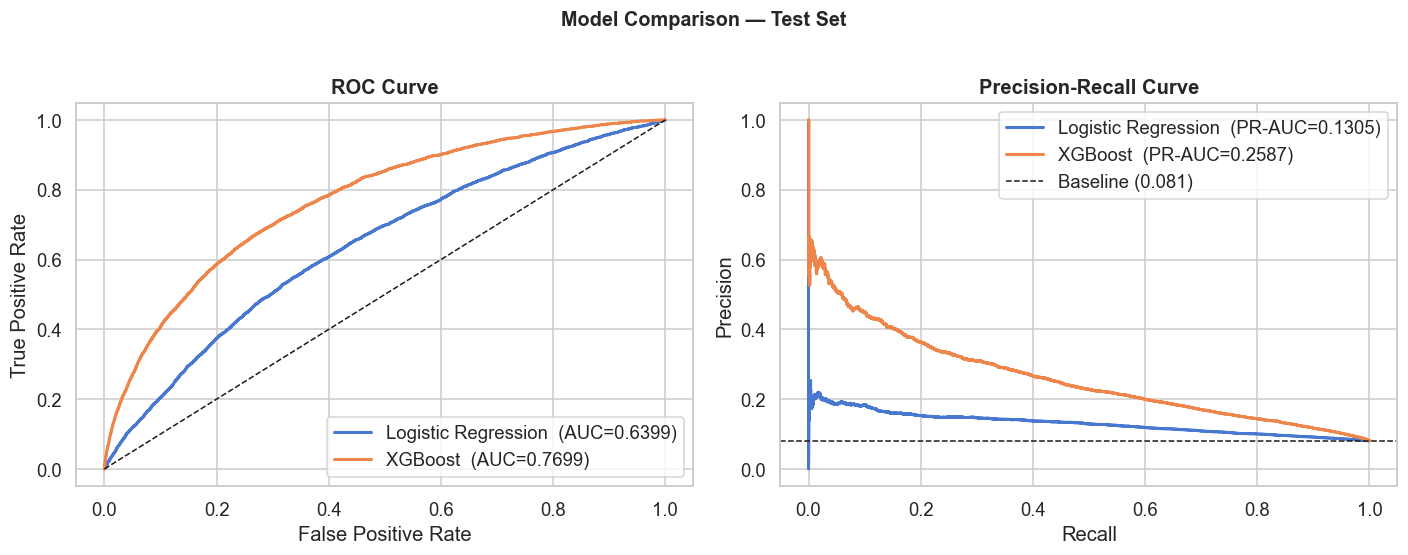

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models = [
    ('Logistic Regression', lr_prob,  lr_metrics),
    ('XGBoost',             xgb_prob, xgb_metrics),
]
colors = sns.color_palette('muted', 2)

# --- ROC ---
ax = axes[0]
for (name, prob, met), color in zip(models, colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name}  (AUC={met["AUC-ROC"]})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve', fontweight='bold')
ax.legend(loc='lower right')

# --- Precision-Recall ---
ax = axes[1]
baseline = y_test.mean()
for (name, prob, met), color in zip(models, colors):
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ax.plot(rec, prec, color=color, lw=2, label=f'{name}  (PR-AUC={met["PR-AUC"]})')
ax.axhline(baseline, color='k', linestyle='--', lw=1, label=f'Baseline ({baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontweight='bold')
ax.legend(loc='upper right')

plt.suptitle('Model Comparison — Test Set', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## 7. Comparison Table

Side-by-side metric summary for quick reference.

In [8]:
comparison = pd.DataFrame(
    {'Logistic Regression': lr_metrics, 'XGBoost': xgb_metrics}
).T

# Highlight: higher is better for AUC-ROC, PR-AUC, KS; lower for Brier
print('\n=== Model Comparison (Test Set) ===')
print(comparison.to_string())

comparison.style.highlight_max(
    subset=['AUC-ROC', 'PR-AUC', 'KS'], color='lightgreen'
).highlight_min(
    subset=['Brier'], color='lightgreen'
)



=== Model Comparison (Test Set) ===
                     AUC-ROC  PR-AUC      KS   Brier
Logistic Regression   0.6399  0.1305  0.2121  0.2378
XGBoost               0.7699  0.2587  0.4025  0.1751


,AUC-ROC,PR-AUC,KS,Brier
Logistic Regression,0.639900,0.130500,0.212100,0.237800
XGBoost,0.769900,0.258700,0.402500,0.175100
